# **Section 8: Support Vector Machine Classification**

In this notebook, I will train and evaluate Support Vector Machine (SVM) models. I will start with a baseline SVM with default parameters, and will then tune the regularization parameter (C) and kernel type using a cross-validated grid search.

## **1. Importing the Data**

Let's import the training, validation, and test data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

# Set pastel color palette for plots
sns.set_palette("pastel")

### **1.1 Load Data**

In [2]:
# Load features and labels
cnv_train = pd.read_csv("Data/cnv_train.csv", index_col=0)
cnv_test = pd.read_csv("Data/cnv_test.csv", index_col=0)
profiles_train = pd.read_csv("Data/SXT_train.csv", index_col=0)
profiles_test = pd.read_csv("Data/SXT_test.csv", index_col=0)

X_train = cnv_train.values
y_train = profiles_train.values

X_test = cnv_test.values
y_test = profiles_test.values

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Categories: {np.unique(y_train)}")

Training set shape: (173, 7197)
Test set shape: (48, 7197)
Categories: [0 1]


## **2. Support Vector Machine with Default Hyperparameters**

Let's start with a baseline SVM using default parameters (linear kernel, C=1.0).

In [3]:
# Create SVM pipeline with standardization
svm = make_pipeline(
    StandardScaler(),
    SVC(kernel='linear', C=1.0, random_state=42)
)

# Train the model
svm.fit(X_train, y_train)
print("SVM model trained")

SVM model trained


### **2.1 Evaluate Baseline Model**

In [5]:
# Evaluate on training, validation, and test sets
accuracy_train = svm.score(X_train, y_train)
accuracy_test = svm.score(X_test, y_test)

print(f"Accuracy training set: {accuracy_train:.4f}")
print(f"Accuracy test set: {accuracy_test:.4f}")

Accuracy training set: 1.0000
Accuracy test set: 0.9792


### **2.2 Classification Report and Confusion Matrix**

In [6]:
# Get predictions
y_test_pred = svm.predict(X_test)

# Classification report
print("Classification Report (Baseline SVM):")
print(classification_report(y_test, y_test_pred))

Classification Report (Baseline SVM):
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        29
           1       1.00      0.95      0.97        19

    accuracy                           0.98        48
   macro avg       0.98      0.97      0.98        48
weighted avg       0.98      0.98      0.98        48



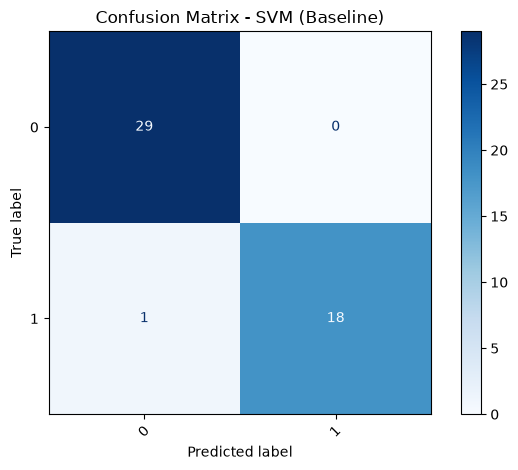

In [7]:
# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred, labels=svm.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm.classes_)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix - SVM (Baseline)")
plt.tight_layout()
plt.show()

## **3. Hyperparameter Tuning: Optimizing C and Kernel**

Now let's use cross-validated grid search to find the optimal regularization parameter (C) and kernel type.

### **3.1 Grid Search for Optimal Hyperparameters**

In [8]:
# Create SVM pipeline for grid search
svm_pipeline = make_pipeline(
    StandardScaler(),
    SVC(random_state=1, probability=True)
)


# Define parameter grid
param_grid = {
    'svc__kernel': ['linear', 'rbf', 'poly'],
    'svc__C': np.logspace(-2, 3, 6)  # 0.01 to 1000
}

# Create grid search
grid_search = GridSearchCV(
    svm_pipeline,
    param_grid,
    cv=5,
    return_train_score=True,
    n_jobs=-1
)

# Perform grid search
grid_search.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")


Best parameters: {'svc__C': np.float64(100.0), 'svc__kernel': 'poly'}
Best cross-validation score: 0.9012


### **3.3 Analyze Grid Search Results**

In [9]:
# Extract results
cv_results = pd.DataFrame(grid_search.cv_results_)

# Display top results
results_display = cv_results[[
    'mean_test_score', 'std_test_score', 
    'mean_train_score', 'std_train_score',
    'param_svc__kernel', 'param_svc__C'
]].sort_values('mean_test_score', ascending=False).head(10)

print("\nTop 10 Grid Search Results:")
print(results_display)


Top 10 Grid Search Results:
    mean_test_score  std_test_score  mean_train_score  std_train_score  \
17         0.901176        0.060804               1.0              0.0   
14         0.901176        0.060804               1.0              0.0   
11         0.895294        0.071379               1.0              0.0   
0          0.889748        0.092148               1.0              0.0   
12         0.889748        0.092148               1.0              0.0   
3          0.889748        0.092148               1.0              0.0   
9          0.889748        0.092148               1.0              0.0   
6          0.889748        0.092148               1.0              0.0   
15         0.889748        0.092148               1.0              0.0   
13         0.872773        0.115720               1.0              0.0   

   param_svc__kernel  param_svc__C  
17              poly       1000.00  
14              poly        100.00  
11              poly         10.00  
0       

### **3.4 Visualize Results by Kernel Type**

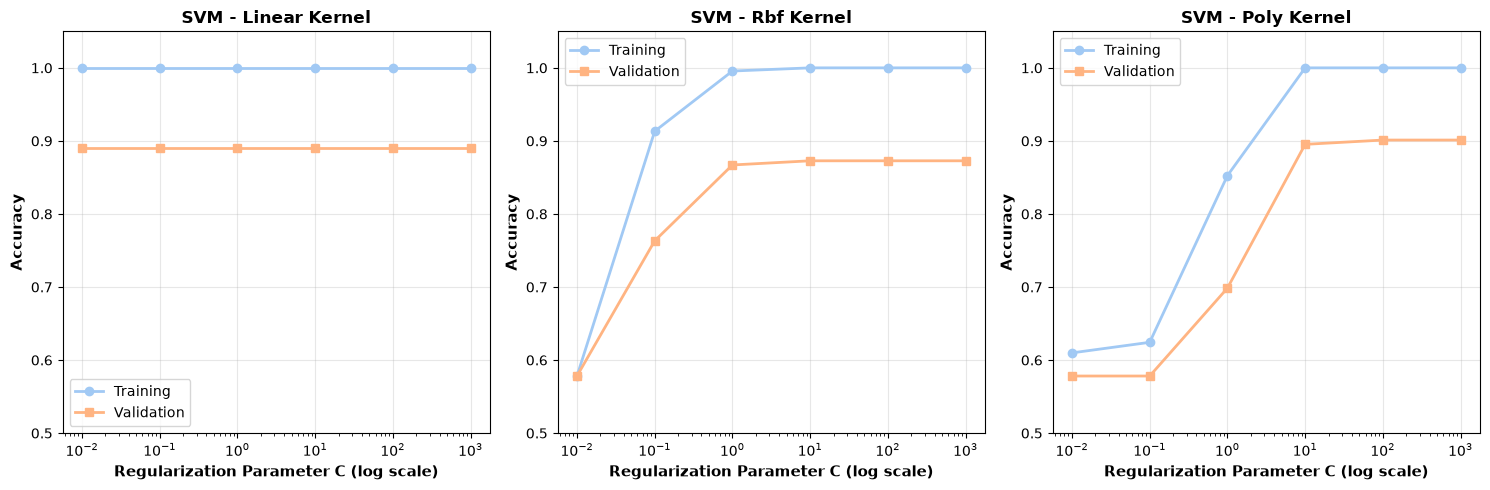

In [10]:
# Separate results by kernel
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
kernels = ['linear', 'rbf', 'poly']

for idx, kernel in enumerate(kernels):
    kernel_results = cv_results[cv_results['param_svc__kernel'] == kernel].sort_values('param_svc__C')
    
    axes[idx].semilogx(
        kernel_results['param_svc__C'],
        kernel_results['mean_train_score'],
        label='Training',
        marker='o',
        linewidth=2
    )
    axes[idx].semilogx(
        kernel_results['param_svc__C'],
        kernel_results['mean_test_score'],
        label='Validation',
        marker='s',
        linewidth=2
    )
    
    axes[idx].set_xlabel('Regularization Parameter C (log scale)', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Accuracy', fontsize=11, fontweight='bold')
    axes[idx].set_title(f'SVM - {kernel.capitalize()} Kernel', fontsize=12, fontweight='bold')
    axes[idx].legend(fontsize=10)
    axes[idx].grid(alpha=0.3)
    axes[idx].set_ylim([0.5, 1.05])

plt.tight_layout()
plt.savefig("Figures/06_svm_training_curve", dpi=300)
plt.show()

## **4. Evaluate Best Model**

In [11]:
# Evaluate best model on test set
best_svm = grid_search.best_estimator_
accuracy_test_best = best_svm.score(X_test, y_test)

print(f"\nBest Model Test Accuracy: {accuracy_test_best:.4f}")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.4f}")


Best Model Test Accuracy: 0.8958
Best parameters: {'svc__C': np.float64(100.0), 'svc__kernel': 'poly'}
Best CV score: 0.9012


### **4.1 Classification Report**

In [12]:
# Get predictions
y_test_pred_best = best_svm.predict(X_test)

# Classification report
print("\nClassification Report (Best SVM):")
print(classification_report(y_test, y_test_pred_best))


Classification Report (Best SVM):
              precision    recall  f1-score   support

           0       0.96      0.86      0.91        29
           1       0.82      0.95      0.88        19

    accuracy                           0.90        48
   macro avg       0.89      0.90      0.89        48
weighted avg       0.90      0.90      0.90        48



### **4.2 Confusion Matrix**

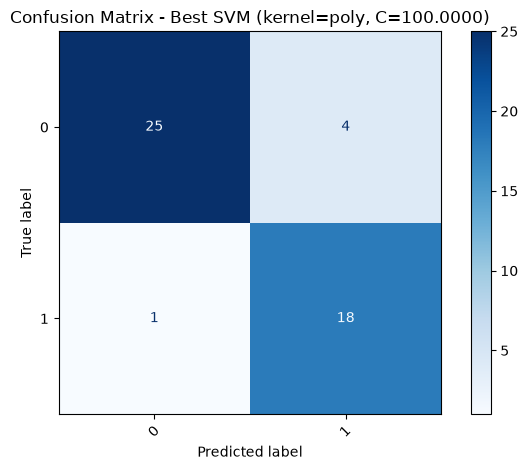

In [13]:
# Confusion matrix
cm_best = confusion_matrix(y_test, y_test_pred_best, labels=best_svm.classes_)
disp_best = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=best_svm.classes_)
disp_best.plot(cmap="Blues", xticks_rotation=45)
plt.title(f"Confusion Matrix - Best SVM (kernel={grid_search.best_params_['svc__kernel']}, C={grid_search.best_params_['svc__C']:.4f})")
plt.tight_layout()
plt.savefig("Figures/06_svm_cm", dpi=300)
plt.show()

### **4.3 ROC curve and AUC score**

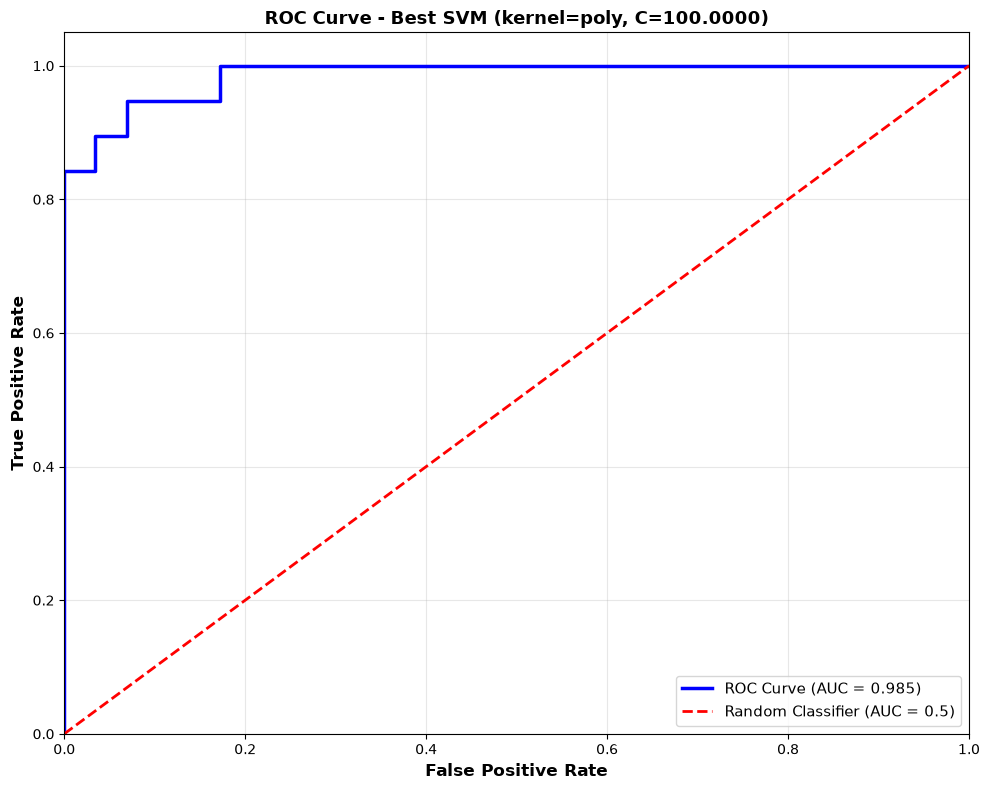


AUC Score: 0.9855


In [14]:
from sklearn.metrics import roc_curve, auc, roc_auc_score

# Get probability predictions for the positive class
y_test_proba = best_svm.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='blue', lw=2.5, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier (AUC = 0.5)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title(f'ROC Curve - Best SVM (kernel={grid_search.best_params_["svc__kernel"]}, C={grid_search.best_params_["svc__C"]:.4f})', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("Figures/06_svm_ROC", dpi=300)
plt.show()

print(f"\nAUC Score: {roc_auc:.4f}")

## **5. Save Results**

In [16]:
import csv
import os

# Store results
results = {
    'model': 'Support Vector Machine',
    'hyperparameters': f"kernel={grid_search.best_params_['svc__kernel']}, C={grid_search.best_params_['svc__C']:.4f}",
    'test_accuracy': float(accuracy_test_best),
    'cv_score': float(grid_search.best_score_)
}

csv_file = 'Results/model_results.csv'

# Append results to the csv file
if not os.path.exists(csv_file):
    with open(csv_file, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=['model', 'hyperparameters', 'test_accuracy', 'cv_score'])
        writer.writeheader()
        writer.writerow(results)
else:
    with open(csv_file, 'a', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=['model', 'hyperparameters', 'test_accuracy', 'cv_score'])
        writer.writerow(results)

print(f"\nResults saved:")
print(f"  Model: {results['model']}")
print(f"  Hyperparameters: {results['hyperparameters']}")
print(f"  Test Accuracy: {results['test_accuracy']:.4f}")
print(f"  CV Score: {results['cv_score']:.4f}")


Results saved:
  Model: Support Vector Machine
  Hyperparameters: kernel=poly, C=100.0000
  Test Accuracy: 0.8958
  CV Score: 0.9012
